# Terminating rays on the boundary sites

waveray traces rays **backward** from the target to pick up the boundary spectra. Where a ray stops — and so which boundary state it samples — is set by `boundary_mode`, which has three options:

| mode | rays stop at | use when |
|---|---|---|
| `"bbox"` (default) | the **grid edge**, interpolated along the perimeter | the output sites sit *on* the grid edge |
| `"line"` | the **open polyline** through the sites | the target is inshore of a transect of sites |
| `"ring"` | the **closed polygon** through the sites | the target is enclosed by a ring of sites |

When the SWAN/WW3 output sites sit **inside** the bathymetry, `"bbox"` keeps propagating each ray past them to the grid edge — so it samples `c*cg` and stops bottom friction at the **edge depth**, not the site depth, and flattens the sites' geometry onto the box perimeter. `"line"` / `"ring"` stop the ray at its first crossing of the line **through the sites** and sample everything there. This notebook shows all three on a self-contained synthetic bathymetry (no Datamesh token needed).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from waveray import BoundaryLine, LocalGrid, build_operator
from waveray.dispersion import group_speed
from waveray.rays import STATUS_EXITED, SpeedField, trace_backward


def bay_bathy(nx=241, ny=241, length=20_000.0, width=20_000.0, d_off=40.0):
    """Plane beach (deep at x=0, shore at x=length) with a shore-parallel
    shoal that refracts rays -- enough 2D structure to be interesting."""
    x = np.linspace(0.0, length, nx)
    y = np.linspace(-width / 2, width / 2, ny)
    xg, yg = np.meshgrid(x, y)
    depth = d_off * (1.0 - xg / length)
    shoal = 14.0 * np.exp(-((xg - 0.62 * length) ** 2) / (2 * 2200.0**2))
    shoal *= np.exp(-(yg**2) / (2 * 5000.0**2))
    return LocalGrid(x=x, y=y, depth=depth - shoal)


def fan_dirs(n=72):
    """n coming-from directions evenly around the circle."""
    return np.arange(0.0, 360.0, 360.0 / n)


def trace_fan(grid, target, f, dirs, boundary_line=None):
    """Backward-trace one ray per direction, recording full paths."""
    fld = SpeedField.build(grid, 2 * np.pi * f, d_min=0.3, cf_jonswap=None)
    dx, dy = grid.spacing
    ds = min(dx, dy) / 3.0
    xmin, xmax, ymin, ymax = grid.bounds
    max_steps = int(np.ceil(1.5 * 2.0 * ((xmax - xmin) + (ymax - ymin)) / ds))
    theta0 = np.deg2rad((270.0 - dirs) % 360.0)  # coming-from deg -> going-to rad
    return trace_backward(
        fld,
        target[0],
        target[1],
        theta0,
        ds=ds,
        max_steps=max_steps,
        d_min=0.3,
        record_paths=True,
        boundary_line=boundary_line,
    )


def draw(ax, grid, fan, title, sites=None, connect=None):
    """Depth backdrop + ray paths. Exit dots are green where a ray stopped
    on the line/ring and red where it escaped to the grid edge; in bbox mode
    every exit is a grid-edge exit. `connect` in {None, 'line', 'ring'}."""
    ax.pcolormesh(grid.x, grid.y, grid.depth, cmap="Blues", shading="auto")
    for i, pts in enumerate(fan.paths):
        if pts.shape[0] < 2:
            continue
        exited = fan.status[i] == STATUS_EXITED
        ax.plot(
            pts[:, 0],
            pts[:, 1],
            color="0.35" if exited else "1.0",
            lw=0.6 if exited else 0.4,
            alpha=0.8,
        )
    ok = fan.status == STATUS_EXITED
    if fan.seg is None:  # bbox mode: every exit is on the grid edge
        ax.scatter(fan.x[ok], fan.y[ok], s=12, c="crimson", zorder=5, label="grid-edge exit")
    else:
        on = ok & (fan.seg >= 0)
        off = ok & (fan.seg < 0)
        ax.scatter(
            fan.x[on],
            fan.y[on],
            s=14,
            c="limegreen",
            ec="k",
            lw=0.3,
            zorder=5,
            label="stops on line",
        )
        if off.any():
            ax.scatter(
                fan.x[off],
                fan.y[off],
                s=14,
                c="crimson",
                zorder=5,
                label="escaped \u2192 nearest site",
            )
    if sites is not None:
        loop = np.vstack([sites, sites[:1]]) if connect == "ring" else sites
        if connect in ("line", "ring"):
            ax.plot(loop[:, 0], loop[:, 1], "-", color="orange", lw=2.2, zorder=4)
        ax.scatter(sites[:, 0], sites[:, 1], s=45, c="orange", ec="k", zorder=6, label="sites")
    ax.set_xlim(*grid.bounds[:2])
    ax.set_ylim(*grid.bounds[2:])
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)

## The three modes at a glance

Same target (yellow star), same eight sites (orange), same 72-ray fan on a flat grid — only `boundary_mode` differs. Green dots are rays that stopped **on** the site geometry; red dots are rays that ran to the **grid edge**.

bbox: escaped rays = n/a (bbox)
line: escaped rays = 10
ring: escaped rays = 0


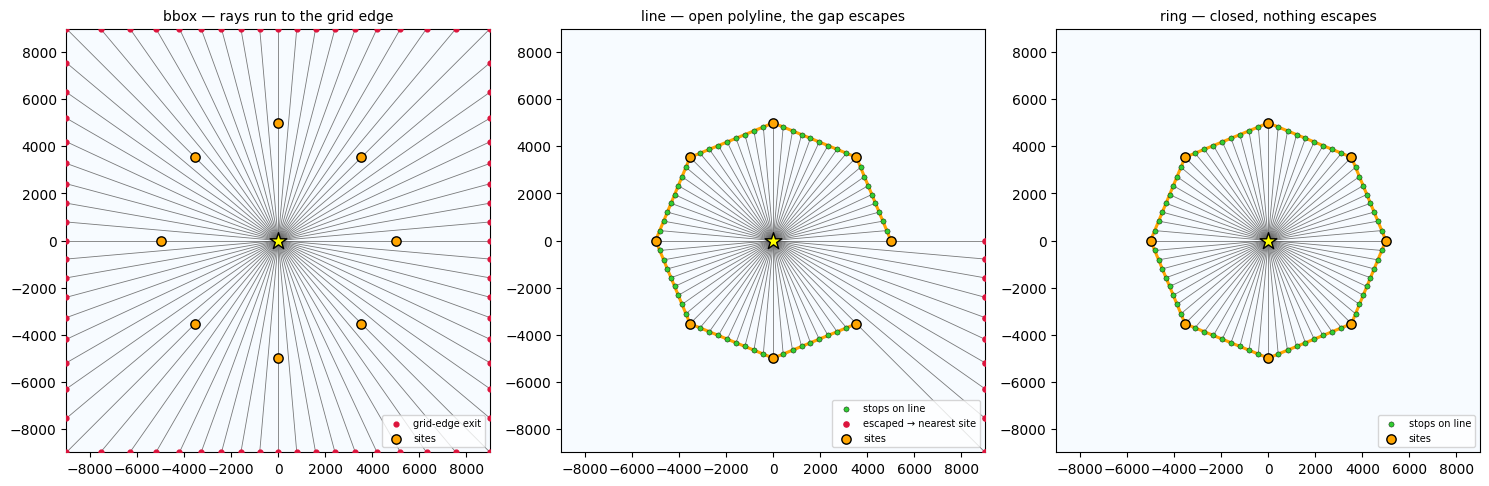

In [2]:
n = 201
flat = LocalGrid(
    x=np.linspace(-9000, 9000, n), y=np.linspace(-9000, 9000, n), depth=np.full((n, n), 30.0)
)
target = (0.0, 0.0)
f = 0.08  # 12.5 s swell
dirs = fan_dirs(72)

ang = np.deg2rad(np.arange(0, 360, 45))
sites8 = np.column_stack([5000 * np.cos(ang), 5000 * np.sin(ang)])  # 8 sites, ring-arranged
open_line = BoundaryLine(x=sites8[:, 0], y=sites8[:, 1])  # 0->1->..->7 (open)
closed_ring = BoundaryLine(x=sites8[:, 0], y=sites8[:, 1], closed=True)  # ..->7->0 (closed)

panels = [
    ("bbox \u2014 rays run to the grid edge", trace_fan(flat, target, f, dirs, None), None),
    (
        "line \u2014 open polyline, the gap escapes",
        trace_fan(flat, target, f, dirs, open_line),
        "line",
    ),
    ("ring \u2014 closed, nothing escapes", trace_fan(flat, target, f, dirs, closed_ring), "ring"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.3))
for ax, (title, fan, connect) in zip(axes, panels, strict=True):
    draw(ax, flat, fan, title, sites=sites8, connect=connect)
    ax.scatter([0.0], [0.0], marker="*", s=160, c="yellow", ec="k", zorder=7)
    ax.legend(loc="lower right", fontsize=7)
fig.tight_layout()

for title, fan, _ in panels:
    esc = "n/a (bbox)" if fan.seg is None else int((fan.seg < 0).sum())
    print(f"{title[:4]}: escaped rays = {esc}")

- **bbox** ignores where the sites actually are: every ray runs to the grid edge (red), and the sites are projected onto the box perimeter for interpolation.
- **line** stops each ray on the open polyline (green) — but the segment between the last and first site is *not* joined, so rays heading into that gap escape to the grid edge (red) and fall back to their nearest site. `build_operator` warns and records `escaped_fraction` when this happens.
- **ring** closes that gap, so every ray in every direction stops on the polygon — the right choice when the target is enclosed.

## Why line / ring change the physics

The point isn't just where the rays stop — it's the **depth** sampled there. On a plane beach, put the target at ~10 m and a five-site transect at ~28 m *inside* the domain (the grid edge is ~40 m). bbox runs the offshore rays past the transect to the 40 m edge; line stops them on the 28 m transect, where the boundary spectrum is actually defined.

/tmp/ipykernel_415651/384398518.py:23: UserWarning: 39.3% of exiting rays reached the grid boundary without crossing the boundary line; they fell back to their nearest site. Widen the line so it spans the ray fan, or use boundary_mode='ring'.
  op_line = build_operator(grid, (x_t, 0.0), sites, boundary_mode="line", **kw)


bbox shoaling ratio : 1.379  (runs to the ~40 m grid edge)
line shoaling ratio : 1.345  (stops at the ~28 m transect)
cg(28 m)/cg(10 m)   : 1.318  (analytic, at the transect depth)
line escaped frac   : 0.39  (alongshore/shoreward rays that miss the one-sided line)


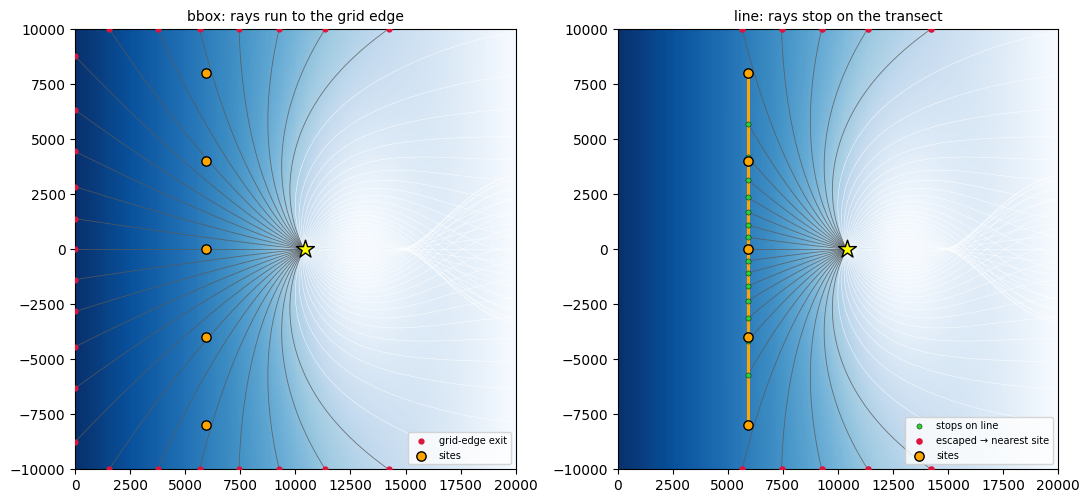

In [3]:
grid = bay_bathy()
depth_y0 = grid.depth[grid.depth.shape[0] // 2]  # depth profile along y = 0
x_t = float(grid.x[np.argmin(np.abs(depth_y0 - 10.0))])  # target ~10 m
x_b = float(grid.x[np.argmin(np.abs(depth_y0 - 28.0))])  # transect ~28 m
sites = np.column_stack([np.full(5, x_b), np.linspace(-8000, 8000, 5)])
line = BoundaryLine(x=sites[:, 0], y=sites[:, 1])

fan_bbox = trace_fan(grid, (x_t, 0.0), f, dirs, boundary_line=None)
fan_line = trace_fan(grid, (x_t, 0.0), f, dirs, boundary_line=line)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
draw(axes[0], grid, fan_bbox, "bbox: rays run to the grid edge", sites=sites)
draw(axes[1], grid, fan_line, "line: rays stop on the transect", sites=sites, connect="line")
for ax in axes:
    ax.scatter([x_t], [0.0], marker="*", s=180, c="yellow", ec="k", zorder=7)
    ax.legend(loc="lower right", fontsize=7)
fig.tight_layout()

# The physical payoff: line mode samples c*cg at the site depth, not the grid edge.
DIRS = np.arange(0.0, 360.0, 10.0)
kw = dict(freqs=np.array([f]), dirs=DIRS, nsub=9, cf_jonswap=None)
op_bbox = build_operator(grid, (x_t, 0.0), sites, boundary_mode="bbox", **kw)
op_line = build_operator(grid, (x_t, 0.0), sites, boundary_mode="line", **kw)

e_b = np.zeros((5, 1, DIRS.size))
e_b[:, 0, DIRS == 270.0] = 1.0  # unit shore-normal swell at every site
omega = 2 * np.pi * f
cg_line = float(group_speed(omega, np.array(28.0)) / group_speed(omega, np.array(10.0)))
print(f"bbox shoaling ratio : {op_bbox.apply(e_b).sum():.3f}  (runs to the ~40 m grid edge)")
print(f"line shoaling ratio : {op_line.apply(e_b).sum():.3f}  (stops at the ~28 m transect)")
print(f"cg(28 m)/cg(10 m)   : {cg_line:.3f}  (analytic, at the transect depth)")
print(
    f"line escaped frac   : {op_line.attrs['escaped_fraction']:.2f}  "
    "(alongshore/shoreward rays that miss the one-sided line)"
)

The offshore rays (green) stop on the orange transect at ~28 m, and the line-mode shoaling coefficient tracks the transect depth rather than the deeper grid edge. Alongshore and shoreward rays miss this one-sided open line — they ground out on the coast (correct) or fall back to the nearest site (the escaped fraction above); a ring, or a transect that spans the full ray fan, removes the fallback.

## Using it

It is one keyword on the high-level builder — the boundary points are the line/ring vertices, taken in the order you supply them:

```python
model = SiteModel.build(
    bathy=bathy,
    target=(lon, lat),
    boundary_points=[(lon1, lat1), (lon2, lat2), ...],  # in along-line order
    freqs=efth.freq.values,
    dirs=efth.dir.values,
    boundary_mode="line",   # "bbox" (default), "line", or "ring"
)
```

`boundary_mode="bbox"` (the default) is unchanged. Use `"line"` / `"ring"` whenever the output sites sit inside the bathymetry rather than on its edge.